# LightGBM Regression — Histogram-Based Gradient Boosting (Leaf-wise Growth)

---

## 1. Problem Setup

Assume a dataset:

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D, \quad y_i \in \mathbb{R}
$$

The goal is to learn a function that predicts continuous targets.

---

## 2. Model Idea

LightGBM builds an additive model:

$$
F(x) = \sum_{m=1}^{M} \eta \, f_m(x)
$$

where:
- $f_m(x)$ is a regression tree  
- $\eta$ is the learning rate  

---

## 3. Initialization

Initial prediction is the mean:

$$
F^{(0)}(x) = \bar{y}
$$

---

## 4. Loss Function

### Mean Squared Error

$$
\mathcal{L} = \frac{1}{2} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$



### Huber Loss

Let:

$$
r_i = y_i - \hat{y}_i
$$

Then the Huber loss is:

$$
\mathcal{L} =
\sum_{i=1}^{N}
\begin{cases}
\frac{1}{2} r_i^2 & \text{if } |r_i| \leq \delta \\
\delta \left(|r_i| - \frac{1}{2}\delta \right) & \text{otherwise}
\end{cases}
$$

where:
- $\delta$ controls the transition between quadratic and linear behavior  
- Quadratic region → behaves like MSE (sensitive to small errors)  
- Linear region → robust to outliers  

---

## 5. Second-Order Approximation

At iteration $t$:

$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{N} \left[
g_i f(x_i) + \frac{1}{2} h_i f(x_i)^2
\right]
$$

where:

$$
g_i = \frac{\partial \mathcal{L}}{\partial \hat{y}_i}, \quad
h_i = \frac{\partial^2 \mathcal{L}}{\partial \hat{y}_i^2}
$$

---

## 6. Gradient and Hessian

### MSE Loss

$$
g_i = \hat{y}_i - y_i
$$

$$
h_i = 1
$$



### Huber Loss

Let:

$$
r_i = \hat{y}_i - y_i
$$

Gradient:

$$
g_i =
\begin{cases}
r_i & |r_i| \leq \delta \\
\delta \cdot \text{sign}(r_i) & \text{otherwise}
\end{cases}
$$

Hessian:

$$
h_i =
\begin{cases}
1 & |r_i| \leq \delta \\
\epsilon & \text{otherwise}
\end{cases}
$$

---

## 7. Tree Structure and Leaf Weights

For a leaf $j$:

$$
G_j = \sum_{i \in I_j} g_i, \quad
H_j = \sum_{i \in I_j} h_i
$$

Optimal weight:

$$
w_j = -\frac{G_j}{H_j + \lambda}
$$

---

## 8. Split Gain

$$
\text{Gain} =
\frac{1}{2} \left(
\frac{G_L^2}{H_L + \lambda} +
\frac{G_R^2}{H_R + \lambda} -
\frac{G^2}{H + \lambda}
\right) - \gamma
$$

Split is accepted only if:

$$
\text{Gain} > 0
$$

---

## 9. Histogram-Based Splitting

Each feature is discretized into bins:

$$
X \rightarrow X_{\text{binned}}
$$

For bin $k$:

$$
G_k = \sum_{i \in \text{bin } k} g_i, \quad
H_k = \sum_{i \in \text{bin } k} h_i
$$

Cumulative sums:

$$
G_{\text{left}} = \sum_{j=1}^{k} G_j
$$

$$
H_{\text{left}} = \sum_{j=1}^{k} H_j
$$

Right side:

$$
G_{\text{right}} = G_{\text{total}} - G_{\text{left}}
$$

$$
H_{\text{right}} = H_{\text{total}} - H_{\text{left}}
$$

---

## 10. Feature Binning

Each feature is discretized using quantiles:

$$
\text{edges}_j = \text{percentiles}(X_j)
$$

$$
X_{\text{binned}} = \text{digitize}(X, \text{edges})
$$

---

## 11. Leaf-wise Tree Growth

Unlike level-wise trees, LightGBM grows trees **leaf-wise**:

- Select the leaf with maximum gain  
- Split that leaf only  
- Continue until:

$$
\text{leaves} = \text{max\_leaves}
$$

or

$$
\text{Gain} \leq 0
$$

---

## 12. Additive Model Update

At each iteration:

$$
F(x) \leftarrow F(x) + \eta \, f_t(x)
$$

---

## 13. Prediction from Trees

Each tree outputs:

$$
f_t(x) = w_j \quad \text{if } x \in \text{leaf } j
$$

---

## 14. Final Prediction

$$
\hat{y}(x) = \hat{y}_{\text{init}} + \eta \sum_{t=1}^{T} f_t(x)
$$

---

## 15. Regularization

LightGBM includes:

- $\lambda$: L2 regularization on leaf weights  
- $\gamma$: penalty for splits  

These control overfitting.

---

## 16. Feature Subsampling

At each split:

$$
\text{features} \subseteq \{1,2,\dots,D\}
$$

---

## 17. Algorithm Summary

For $t = 1$ to $T$:

$$
\text{Compute gradients } g_i
$$

$$
\text{Compute hessians } h_i
$$

$$
\text{Bin features into histograms}
$$

$$
\text{Find best split using histogram gain}
$$

$$
\text{Grow tree leaf-wise}
$$

$$
F(x) \leftarrow F(x) + \eta \, f_t(x)
$$

---


## 18. Intuition

- Uses **histograms** → faster than exact split search  
- Uses **leaf-wise growth** → deeper, more accurate trees  
- Uses **second-order gradients** → better optimization  
- Regularization controls overfitting  
- Learning rate stabilizes updates  

---



In [1]:
class LeafNode:
    """
    Represents a leaf in the LightGBM tree.

    Stores:
    - indices of samples
    - sum of gradients (G) and hessians (H)
    - leaf prediction value
    - best split info (for leaf-wise growth)
    """
    def __init__(self, indices, G, H, value):
        self.indices = indices  # data points in this node
        self.G = G              # sum of gradients
        self.H = H              # sum of hessians
        self.value = value      # leaf weight = -G / (H + lambda)

        # best split info
        self.best_feature = None
        self.best_threshold = None
        self.best_gain = -np.inf

        # children (if split happens)
        self.left = None
        self.right = None

In [2]:
class LightGBMTree:
    """
    Histogram-based LightGBM tree (leaf-wise growth).

    Uses:
    - Gradient & Hessian for second-order optimization
    - Histogram binning for fast split search
    - Leaf-wise (best-first) expansion
    """
    def __init__(self,max_leaves=10,min_samples_leaf=10,lambda_=1,gamma=0,feature_fraction=1,max_bin=256):
        self.max_leaves= max_leaves              # max number of leaves
        self.min_samples_leaf = min_samples_leaf # min samples per leaf
        self.lambda_ = lambda_                   # L2 regularization
        self.gamma = gamma                       # min gain to split
        self.feature_fraction = feature_fraction # feature subsampling
        self.max_bin=max_bin                     # number of histogram bins

        self.num_features = None
        self.X_binned = None
        self.g = None
        self.h = None

        

        # Validate
        if type(self.max_leaves) != int or self.max_leaves <= 0:
            raise ValueError('Max leaves must be a positive integer')
        if type(self.min_samples_leaf) != int or self.min_samples_leaf <= 0:
            raise ValueError('Min samples leaf must be a positive integer')
        if self.lambda_ < 0:
            raise ValueError("lambda must be positive")
        if self.gamma < 0:
            raise ValueError("gamma must be positive")
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if type(self.max_bin) != int or self.max_bin <= 0:
            raise ValueError('Max bins must be a positive integer')

    def _computeGH(self,indices):
        """Compute sum of gradients (G) and hessians (H) for given indices."""
        G = np.sum(self.g[indices])
        H = np.sum(self.h[indices])
        return G, H

    def _leaf_weight(self,G,H):
        """Compute optimal leaf value: w = -G / (H + lambda)."""
        eps =1e-10
        weight = -G/(H+self.lambda_ + eps)
        return weight

    def _feature_sampling(self):
        """Randomly sample a subset of features."""
        num_sampled_features = max(1,int(round(self.feature_fraction*self.num_features)))
        selected_features = np.random.choice(self.num_features,num_sampled_features,replace=False)
        return selected_features 

    def _build_histogram(self, indices, feature):
        """Build histogram of gradients and hessians for a feature."""
        G_bins = np.zeros(self.max_bin)
        H_bins = np.zeros(self.max_bin)

        for idx in indices:
            b = self.X_binned[idx, feature] # bin index
            G_bins[b] += self.g[idx]
            H_bins[b] += self.h[idx]

        return G_bins, H_bins

    def _compute_node_score(self,G,H):
        """Node score: G^2 / (H + lambda)."""
        eps =1e-10
        score = G**2 /(H + self.lambda_ + eps)
        return score

    def _compute_gain(self,parent_score,left_score,right_score):
        """Split gain with regularization."""
        return 0.5*(left_score + right_score - parent_score) - self.gamma

    def _split(self, indices, feature, threshold_bin):
        """Split indices based on feature and bin threshold."""
        mask = self.X_binned[indices, feature] <= threshold_bin
        return indices[mask], indices[~mask]    
           
    def _best_feature_threshold_score(self,selected_features,indices):
        """Find best split across features using histograms."""
        best_threshold = None
        best_feature = None
        best_gain = -np.inf

        G_parent, H_parent = self._computeGH(indices)
        parent_score = self._compute_node_score(G_parent, H_parent)

        for feature in selected_features:

            G_bins, H_bins = self._build_histogram(indices, feature)

            G_left, H_left = 0.0, 0.0
            G_total, H_total = np.sum(G_bins), np.sum(H_bins)

            # scan bins
            for k in range(self.max_bin - 1):
                G_left += G_bins[k]
                H_left += H_bins[k]

                G_right = G_total - G_left
                H_right = H_total - H_left

                if H_left < 1e-10 or H_right < 1e-10:
                    continue

                left_score = self._compute_node_score(G_left, H_left)
                right_score = self._compute_node_score(G_right, H_right)

                gain = self._compute_gain(parent_score, left_score, right_score)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = k

        return best_feature, best_threshold, best_gain

    def _find_best_split(self,indices):
        """Wrapper to sample features and find best split."""
        selected_features = self._feature_sampling()
        best_feature, best_threshold, best_gain = self._best_feature_threshold_score(selected_features,indices)

        return best_feature, best_threshold, best_gain

    def fit(self,X,g,h):
        """Train tree using leaf-wise growth."""
        X = np.asarray(X)
        g = np.asarray(g)
        h = np.asarray(h)

        self.X_binned =X
        self.g =g
        self.h = h

        N , self.num_features = self.X_binned.shape

        indices = np.arange(N)
        
        # initialize root
        G , H = self._computeGH(indices)
        value = self._leaf_weight(G,H)

        self.root =  LeafNode(indices,G,H,value=value)
        leaves = [self.root]
        
        # grow tree
        while len(leaves) < self.max_leaves:
            # compute best split for each leaf
            for leaf in leaves:
                best_feature, best_threshold, best_gain = self._find_best_split(leaf.indices)
                leaf.best_feature = best_feature
                leaf.best_threshold = best_threshold
                leaf.best_gain = best_gain
                
            # pick leaf with max gain
            best_leaf = max(leaves, key=lambda leaf: leaf.best_gain)
            
            if best_leaf.best_gain<=0:
                break
            if best_leaf.best_feature is None:
                break

            left_indices, right_indices = self._split(best_leaf.indices,best_leaf.best_feature,best_leaf.best_threshold)

            if len(left_indices) == 0 or len(right_indices) == 0:
                break

            # create children
            G_L , H_L = self._computeGH(left_indices)
            G_R, H_R = self._computeGH(right_indices)

            left_child = LeafNode(left_indices, G_L, H_L, self._leaf_weight(G_L, H_L))
            right_child = LeafNode(right_indices, G_R, H_R, self._leaf_weight(G_R, H_R))

            best_leaf.left = left_child
            best_leaf.right = right_child

            # update leaf list
            leaves.remove(best_leaf)
            leaves.append(left_child)
            leaves.append(right_child)
            
    def _predict_single(self, x, node):
        """Traverse tree for a single sample."""
        if node.left is None and node.right is None:
            return node.value

        if node.best_feature is None:
            return node.value

        if x[node.best_feature] <= node.best_threshold:
            return self._predict_single(x, node.left)
        else:
            return self._predict_single(x, node.right)


    def predict(self, X_binned):
        """Predict for all samples."""
        return np.array([self._predict_single(x, self.root) for x in X_binned])

    def count_leaves(self,node):
        """Count total leaf nodes."""
        if node.left is None and node.right is None:
            return 1
        return self.count_leaves(node.left) + self.count_leaves(node.right)   

    def _unique_weights(self, node):
        """A list of all floating-point weights stored in the leaves."""
        if node.left is None and node.right is None:
            return [node.value]
        # Combine weights from left and right branches
        return self._unique_weights(node.left) + self._unique_weights(node.right)

In [3]:
class LightGBMRegression:
    """
    Histogram-based Gradient Boosting Regressor (LightGBM-style).

    Key ideas:
    - Uses second-order gradients (gradient + hessian)
    - Histogram-based feature binning
    - Leaf-wise tree growth
    - Supports MSE and Huber loss
    """
    def __init__(self,n_estimators=100,max_leaves=10,min_samples_leaf=10,lambda_=1,gamma=0,feature_fraction=1,learning_rate=0.01,loss='mse',
                delta=1, max_bin=256 , random_state =123):
        """
        Initialize model hyperparameters.
        """
        self.n_estimators = n_estimators
        self.max_leaves = max_leaves
        self.min_samples_leaf = min_samples_leaf
        self.lambda_ = lambda_
        self.gamma = gamma
        self.feature_fraction = feature_fraction
        self.learning_rate = learning_rate
        self.loss = loss
        self.delta= delta
        self.max_bin = max_bin
        self.random_state = random_state
        
        self.bin_edges = None
        self.all_models = None

        # Validate
        if type(self.n_estimators) != int or self.n_estimators <= 0:
            raise ValueError('N estimators must be a positive integer')
        if type(self.max_leaves) != int or self.max_leaves <= 0:
            raise ValueError('Max leaves must be a positive integer')
        if type(self.min_samples_leaf) != int or self.min_samples_leaf <= 0:
            raise ValueError('Min samples leaf must be a positive integer')
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.gamma < 0:
            raise ValueError("gamma must be positive")
        if self.lambda_ < 0:
            raise ValueError("lambda must be positive")
        if self.learning_rate <= 0:
            raise ValueError("learning rate must be positive")
        if self.loss not in ['mse','huber']:
            raise ValueError("loss function can be either 'mse' or 'huber'")
        if self.delta <= 0:
            raise ValueError("delta must be positive")
        if type(self.max_bin) != int or self.max_bin <= 0:
            raise ValueError('Max bins must be a positive integer')

    def _bin_features(self, X):
        """
        Convert continuous features into discrete bins using quantiles.
        Stores bin edges for later use in prediction.
        """
        X = np.asarray(X)
        n_samples, n_features = X.shape
        
        X_binned = np.zeros_like(X, dtype=np.int32)
        self.bin_edges = []
    
        for j in range(n_features):
            # Quantile-based bins
            percentiles = np.linspace(0, 100, self.max_bin + 1)
            edges = np.percentile(X[:, j], percentiles)
    
            # Remove duplicates (important)
            edges = np.unique(edges)
    
            self.bin_edges.append(edges)
    
            # Assign bins
            X_binned[:, j] = np.digitize(X[:, j], edges[1:-1])
    
        return X_binned
        
    def _apply_binning(self, X):
        """
        Apply stored bin edges to new data.
        """
        X = np.asarray(X)
        X_binned = np.zeros_like(X, dtype=np.int32)

        for j in range(X.shape[1]):
            edges = self.bin_edges[j]
            X_binned[:, j] = np.digitize(X[:, j], edges[1:-1])

        return X_binned

    def _compute_residual(self,y,y_pred):
        """Compute residual: (y_pred - y)."""
        return y_pred - y

    def _compute_gradient_hessian(self,y,y_pred):
        if self.loss == 'mse':
            gradient = self._compute_residual(y,y_pred)
            hessian = np.ones_like(y,dtype=float)
            
        elif self.loss =='huber':
            residual = self._compute_residual(y,y_pred)
            abs_r = np.abs(residual)
            gradient = np.where(abs_r <=self.delta,residual , self.delta * np.sign(residual))
            hessian = np.where(abs_r <= self.delta, 1 , 1e-10)

        return gradient , np.maximum(hessian, 1e-10)

    def fit(self,X,y):
        """
        Train the LightGBM model using boosting.

        Steps:
        1. Bin features
        2. Initialize prediction with mean
        3. Iteratively fit trees on gradients
        4. Update predictions
        """
        np.random.seed(self.random_state)
        # Ensure inputs are in a consistent numpy format
        X = np.asarray(X)
        y = np.asarray(y)
        # Reshape X to 2D if a single feature is passed
        if X.ndim==1:
            X = X.reshape(-1,1)

        y = y.reshape(-1)

        self.all_models = []

        X_binned = self._bin_features(X)

        self.initial_prediction = np.mean(y)
        y_pred = np.full_like(y,self.initial_prediction,dtype=float)

        for m in range(self.n_estimators):
            gradient , hessian = self._compute_gradient_hessian(y,y_pred)

            model = LightGBMTree(max_leaves=self.max_leaves,min_samples_leaf=self.min_samples_leaf,
                                 lambda_=self.lambda_ ,gamma=self.gamma,feature_fraction=self.feature_fraction,
                                max_bin = self.max_bin)

            model.fit(X_binned,gradient,hessian)

            y_out = model.predict(X_binned)
            y_pred += self.learning_rate*y_out

            self.all_models.append(model)


    def predict(self, X):
        """
        Predict outputs by aggregating all trees.

        Final prediction:
        y = initial_prediction + sum(learning_rate * tree_output)
        """
        X_binned = self._apply_binning(X)

        y_pred = np.full(X.shape[0], self.initial_prediction, dtype=float)

        for tree in self.all_models:
            y_pred += self.learning_rate * tree.predict(X_binned)

        return y_pred    

# Effect of Histogram Binning (`max_bin`) on LightGBM Performance

---

## 1. Objective

The objective is to study how the **number of histogram bins (`max_bin`)** affects:

- Model performance  
- Generalization  
- Sensitivity to noise  

Compare two loss functions:

- Mean Squared Error (MSE)  
- Huber Loss  

---

## 2. Background

LightGBM uses **histogram-based splitting**, where continuous features are discretized into bins.

Let a feature be discretized into $K$ bins:

$$
X \rightarrow X_{\text{binned}} \in \{0, 1, \dots, K-1\}
$$

Each bin aggregates gradient and hessian:

$$
G_k = \sum_{i \in \text{bin } k} g_i, \quad
H_k = \sum_{i \in \text{bin } k} h_i
$$

---

## 3. Role of `max_bin`

- Small $K$ (low `max_bin`):
  - Coarse approximation  
  - Faster computation  
  - Risk of **underfitting**

- Large $K$ (high `max_bin`):
  - Fine-grained splits  
  - Better fit to data  
  - Risk of **overfitting**

---

## 4. Loss Functions

### 4.1 Mean Squared Error (MSE)

$$
\mathcal{L}_{\text{MSE}} = \frac{1}{2} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

Gradient:

$$
g_i = \hat{y}_i - y_i
$$

Hessian:

$$
h_i = 1
$$



### 4.2 Huber Loss

Let:

$$
r_i = \hat{y}_i - y_i
$$

Loss:

$$
\mathcal{L}_{\text{Huber}} =
\begin{cases}
\frac{1}{2} r_i^2 & |r_i| \leq \delta \\
\delta \left(|r_i| - \frac{1}{2}\delta \right) & \text{otherwise}
\end{cases}
$$

Gradient:

$$
g_i =
\begin{cases}
r_i & |r_i| \leq \delta \\
\delta \cdot \text{sign}(r_i) & \text{otherwise}
\end{cases}
$$

Hessian:

$$
h_i =
\begin{cases}
1 & |r_i| \leq \delta \\
\epsilon & \text{otherwise}
\end{cases}
$$

---

## 5. Observations

### 5.1 MSE Behavior

- For small bins:
  - Model is too simple  
  - High bias  
  - High error  

- As bins increase:
  - Model captures structure better  
  - Test loss decreases  

- After a point:
  - Model becomes too flexible  
  - Fits noise  
  - Test loss increases  


$$
\text{Test Error} \downarrow \rightarrow \text{Optimal} \rightarrow \uparrow
$$


### 5.2 Huber Behavior

- More stable than MSE  
- Less sensitive to outliers  


---



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset 

def make_regression_data(n_samples=1000, noise=0.2, random_state=42):
    np.random.seed(random_state)
    
    X = np.random.uniform(-3, 3, (n_samples, 2))
    y = np.sin(X[:,0]) + np.cos(X[:,1])
    
    y += noise * np.random.randn(n_samples)
    
    return X, y

X, y = make_regression_data()

In [5]:
# Train-Test Split

np.random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.7 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

In [6]:
# Experiment Setup
max_bins = [4, 8, 16, 32, 64, 128, 256, 1024]

mse_train, mse_test = [], []
huber_train, huber_test = [], []

delta = 1

# Huber Loss calculation
def huber_loss(y_true, y_pred, delta):
    r = y_pred - y_true
    condition = np.abs(r) <= delta
    loss = np.where(condition, 0.5 * r**2, delta * (np.abs(r) - 0.5 * delta))
    return np.mean(loss)
    
# Run 
for mb in max_bins:
    
    # MSE Model 
    model_mse = LightGBMRegression(
        n_estimators=100,
        max_leaves=10,
        learning_rate=0.01,
        lambda_=1,
        gamma=0,
        max_bin=mb,
        loss='mse'
    )
    
    model_mse.fit(X_train, y_train)
    
    pred_train = model_mse.predict(X_train)
    pred_test = model_mse.predict(X_test)
    
    mse_train.append(np.mean((y_train - pred_train)**2))
    mse_test.append(np.mean((y_test - pred_test)**2))
    
    
    # Huber Model
    model_huber = LightGBMRegression(
        n_estimators=100,
        max_leaves=10,
        learning_rate=0.01,
        lambda_=1,
        gamma=0,
        max_bin=mb,
        loss='huber',
        delta=delta
    )
    
    model_huber.fit(X_train, y_train)
    
    pred_train = model_huber.predict(X_train)
    pred_test = model_huber.predict(X_test)
    
    huber_train.append(huber_loss(y_train, pred_train, delta))
    huber_test.append(huber_loss(y_test, pred_test, delta))

In [7]:
# Optimal Loss points
opt_mse_idx = np.argmin(mse_test)
opt_huber_idx = np.argmin(huber_test)

opt_mse_bin = max_bins[opt_mse_idx]
opt_huber_bin = max_bins[opt_huber_idx]

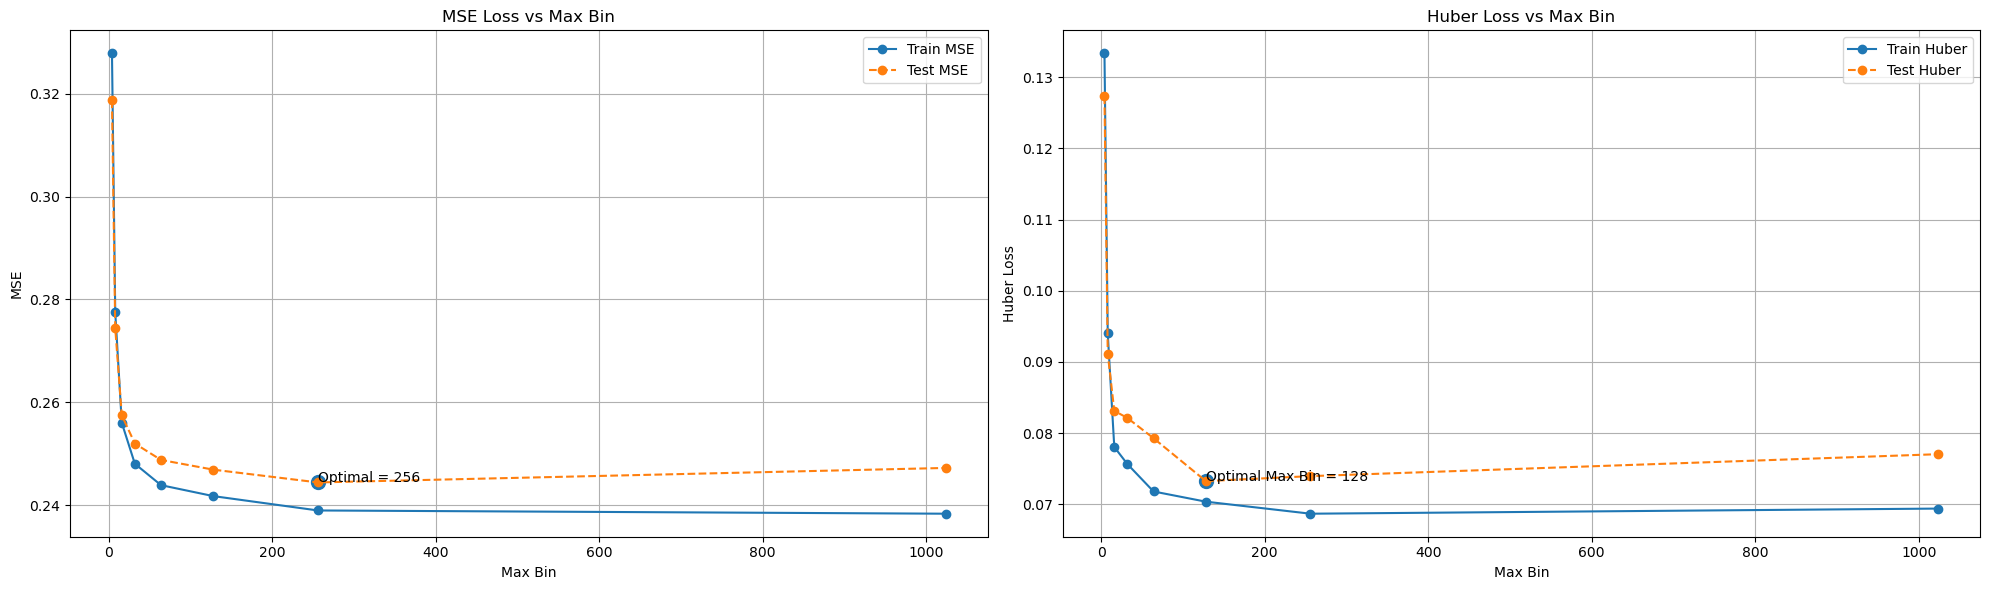

In [8]:
# Plot
plt.figure(figsize=(20,6))

# MSE Plot 
plt.subplot(1,2,1)
plt.plot(max_bins, mse_train, marker='o', label="Train MSE")
plt.plot(max_bins, mse_test, marker='o', linestyle='--', label="Test MSE")

plt.scatter(opt_mse_bin, mse_test[opt_mse_idx], s=100)
plt.text(opt_mse_bin, mse_test[opt_mse_idx],
         f"Optimal = {opt_mse_bin}", fontsize=10)

plt.xlabel("Max Bin")
plt.ylabel("MSE")
plt.title("MSE Loss vs Max Bin")
plt.legend()
plt.grid(True)

# Huber Plot 
plt.subplot(1,2,2)
plt.plot(max_bins, huber_train, marker='o', label="Train Huber")
plt.plot(max_bins, huber_test, marker='o', linestyle='--', label="Test Huber")

plt.scatter(opt_huber_bin, huber_test[opt_huber_idx], s=100)
plt.text(opt_huber_bin, huber_test[opt_huber_idx],
         f"Optimal Max Bin = {opt_huber_bin}", fontsize=10)

plt.xlabel("Max Bin")
plt.ylabel("Huber Loss")
plt.title("Huber Loss vs Max Bin")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Bias–Variance Interpretation

- **Small $max\_bin$ (Underfitting):** High Bias, Low Variance.  
  The coarse histogram fails to capture the underlying signal, leading to high error on both train and test sets.

- **Large $max\_bin$ (Overfitting):** Low Bias, High Variance.  
  The model gains too much resolution, capturing stochastic noise ($\epsilon = 0.2$) and causing the test error to increase.

- **Optimal $max\_bin$:** The sweet spot  
  $$
  K \approx 128 \text{--} 256
  $$  
  where generalization is maximized.

---

## 8. Key Insights

- **Resolution Control:**  
  $max\_bin$ acts as a complexity regulator. Increasing it improves model capacity but risks memorizing noise.

- **Loss Robustness:**  
  Huber loss is more stable than MSE at high bin counts, as its linear gradient penalty reduces sensitivity to outliers.

- **Efficiency:**  
  Gains diminish rapidly beyond  
  $$
  K = 256
  $$  
  which justifies the default choice in LightGBM.

---

## 9. Conclusion

The experiment shows that $max\_bin$ is a crucial regularization parameter.

For noisy datasets, increasing bins beyond  
$$
256
$$  
does not improve generalization and instead increases variance and computational cost.

---